<a href="https://colab.research.google.com/github/sarangraje/Data_Science_Python_and_R/blob/main/Biostats_Project_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [2]:
df.columns = df.columns.str.title()

In [3]:
df["Diabetes"] = df["Diabetes"].map({1: "Yes", 0: "No"})
df["High_Blood_Pressure"] = df["High_Blood_Pressure"].map({1: "Yes", 0: "No"})
df["Sex"] = df["Sex"].map({1: "Male", 0: "Female"})

In [ ]:
df

,Age,Anaemia,Creatinine_Phosphokinase,Diabetes,Ejection_Fraction,High_Blood_Pressure,Platelets,Serum_Creatinine,Serum_Sodium,Sex,Smoking,Time,Death_Event
0,75.0,0,582,No,20,Yes,265000.00,1.9,130,Male,0,4,1
1,55.0,0,7861,No,38,No,263358.03,1.1,136,Male,0,6,1
2,65.0,0,146,No,20,No,162000.00,1.3,129,Male,1,7,1
3,50.0,1,111,No,20,No,210000.00,1.9,137,Male,0,7,1
4,65.0,1,160,Yes,20,No,327000.00,2.7,116,Female,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,Yes,38,Yes,155000.00,1.1,143,Male,1,270,0
295,55.0,0,1820,No,38,No,270000.00,1.2,139,Female,0,271,0
296,45.0,0,2060,Yes,60,No,742000.00,0.8,138,Female,0,278,0
297,45.0,0,2413,No,38,No,140000.00,1.4,140,Male,1,280,0


In [ ]:
%reload_ext sql
%sql sqlite://
import sqlite3
import pandas as pd

conn = sqlite3.connect(":memory:")

In [ ]:
df.to_sql("df", conn, index=False, if_exists="replace")

299

In [ ]:
query = "SELECT * FROM df"
result = pd.read_sql_query(query, conn)

result

,Age,Anaemia,Creatinine_Phosphokinase,Diabetes,Ejection_Fraction,High_Blood_Pressure,Platelets,Serum_Creatinine,Serum_Sodium,Sex,Smoking,Time,Death_Event
0,75.0,0,582,No,20,Yes,265000.00,1.9,130,Male,0,4,1
1,55.0,0,7861,No,38,No,263358.03,1.1,136,Male,0,6,1
2,65.0,0,146,No,20,No,162000.00,1.3,129,Male,1,7,1
3,50.0,1,111,No,20,No,210000.00,1.9,137,Male,0,7,1
4,65.0,1,160,Yes,20,No,327000.00,2.7,116,Female,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,Yes,38,Yes,155000.00,1.1,143,Male,1,270,0
295,55.0,0,1820,No,38,No,270000.00,1.2,139,Female,0,271,0
296,45.0,0,2060,Yes,60,No,742000.00,0.8,138,Female,0,278,0
297,45.0,0,2413,No,38,No,140000.00,1.4,140,Male,1,280,0


In [ ]:
query = '''
SELECT Sex, AVG(Age) AS Average_Age
FROM df
GROUP BY Sex
'''
result = pd.read_sql_query(query, conn)

result

,Sex,Average_Age
0,Female,59.777781
1,Male,61.405500


In [ ]:
query = '''
SELECT Sex, high_Blood_Pressure, Round(AVG(Platelets),2) AS Average_Platelets
FROM df
GROUP BY Sex, high_Blood_Pressure
HAVING Average_Platelets > 10000
ORDER BY Sex, high_Blood_Pressure
;
'''
result = pd.read_sql_query(query, conn)

result

,Sex,High_Blood_Pressure,Average_Platelets
0,Female,No,273904.07
1,Female,Yes,288365.32
2,Male,No,253286.00
3,Male,Yes,256734.26


In [ ]:
query = '''
SELECT DEATH_EVENT, AVG(Ejection_fraction) AS Average_Ejection_FRcation
FROM df
GROUP BY DEATH_EVENT
;
'''
result = pd.read_sql_query(query, conn)

result

,Death_Event,Average_Ejection_FRcation
0,0,40.26601
1,1,33.46875


In [ ]:
query = '''
SELECT Age, Serum_Creatinine
FROM df
WHERE Diabetes == "Yes"
ORDER BY Serum_Creatinine DESC
LIMIT 5
;
'''
result = pd.read_sql_query(query, conn)

result

,Age,Serum_Creatinine
0,60.0,6.8
1,60.0,6.1
2,69.0,3.5
3,53.0,3.4
4,60.0,3.0


In [ ]:
query = '''
SELECT Sex, Count(SEX) AS Count_of_Sex
FROM df
WHERE High_blood_Pressure == "Yes" AND Smoking == "1"
GROUP BY Sex
;
'''
result = pd.read_sql_query(query, conn)

result

,Sex,Count_of_Sex
0,Female,3
1,Male,27


In [ ]:
query = '''
SELECT Diabetes, MIN(Age) AS Min_Age, MAX(Age) AS Max_Age, FLOOR(AVG(Age)) AS Average_Age
FROM df
WHERE DEATH_EVENT == "1"
GROUP BY Diabetes
;
'''
result = pd.read_sql_query(query, conn)

result

,Diabetes,Min_Age,Max_Age,Average_Age
0,No,45.0,95.0,66.0
1,Yes,42.0,94.0,62.0


In [ ]:
query = '''
SELECT Serum_Creatinine, COUNT(Serum_Creatinine) AS Count_of_Serum_Creatinine
FROM df
WHERE Ejection_fraction < 40
GROUP BY Serum_Creatinine
ORDER BY Count_of_Serum_Creatinine DESC
;
'''
result = pd.read_sql_query(query, conn)

result

,Serum_Creatinine,Count_of_Serum_Creatinine
0,1.00,25
1,1.10,22
2,0.90,19
3,1.20,16
4,0.80,13
5,1.30,12
6,1.83,8
7,1.70,8
8,1.40,7
9,0.70,7


In [ ]:
query = '''
WITH cte AS (
SELECT Diabetes, FLOOR(AVG(Age)) AS Avg_Age, Round(AVG(Ejection_fraction),2) AS Avg_Ejection_Fraction
FROM df
WHERE Death_Event == 0
GROUP BY Diabetes
)
SELECT * FROM cte
;
'''
result = pd.read_sql_query(query, conn)

result

,Diabetes,Avg_Age,Avg_Ejection_Fraction
0,No,59.0,40.86
1,Yes,57.0,39.44


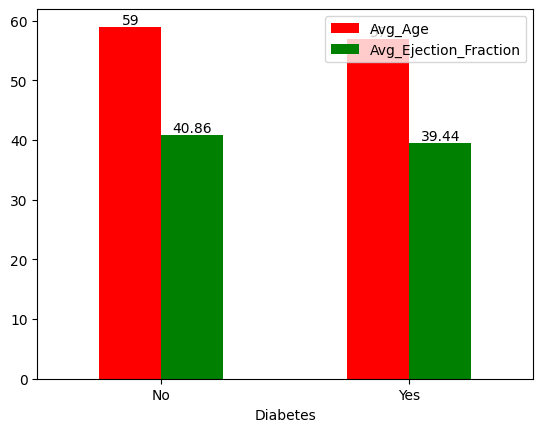

In [ ]:
ax = result.set_index("Diabetes").plot(kind = "bar", color = ['red', "green"], rot = 0)

for container in ax.containers:
  ax.bar_label(container)

<Axes: xlabel='Visit_Date'>

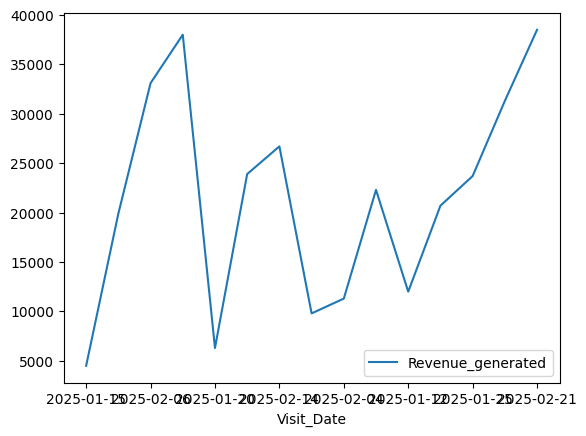

In [ ]:
query = '''
SELECT Hospital_Name, d_v.Patient_ID, Visit_date, Hospital_Bill, SUM(Hospital_Bill) OVER (PARTITION BY Hospital_Name ORDER BY Visit_Date) AS Revenue_generated
FROM df_hos_info d_h_i
JOIN df_visit d_v
ON d_h_i.Hospital_ID = d_v.Hospital_ID
;
'''
result = pd.read_sql_query(query, conn)

result.plot(x = "Visit_Date", y = "Revenue_generated", kind = "line")

In [ ]:
query = '''
SELECT Age, Smoking, Ejection_fraction, MAX(Ejection_fraction) OVER (PARTITION BY Age, Smoking) AS Max_Ejection_Fraction
FROM df
GROUP BY Age, Smoking, Ejection_fraction
;
'''
result = pd.read_sql_query(query, conn)

result

,Age,Smoking,Ejection_Fraction,Max_Ejection_Fraction
0,40.0,0,30,45
1,40.0,0,35,45
2,40.0,0,40,45
3,40.0,0,45,45
4,40.0,1,35,35
...,...,...,...,...
206,90.0,0,50,50
207,90.0,1,40,40
208,94.0,0,38,38
209,95.0,0,30,40


In [ ]:
query = '''
SELECT Hospital_Name, City, Round(AVG(Length_of_stay),2) AS Avg_LOS
FROM df_visit d_v
JOIN df_hos_info d_h_i
ON d_v.Hospital_ID = d_h_i.Hospital_id
GROUP BY Hospital_Name, City
HAVING Avg_LOS > 4
;
'''
result = pd.read_sql_query(query, conn)

result

,Hospital_Name,City,Avg_LOS
0,Baystate Medical Center,Springfield,5.25
1,Brigham and Women's Hospital,Boston,5.00
2,Holyoke Medical Center,Holyoke,4.33
3,Mass General Hospital,Boston,4.60


In [ ]:
query = '''
SELECT Age, serum_sodium, high_blood_pressure
FROM df
WHERE serum_sodium > (
SELECT Round(AVG(serum_sodium),2)
FROM df
WHERE Death_event = 1
)
;
'''
result = pd.read_sql_query(query, conn)

result

,Age,Serum_Sodium,High_Blood_Pressure
0,55.0,136,No
1,50.0,137,No
2,75.0,137,No
3,65.0,138,No
4,62.0,140,Yes
...,...,...,...
195,62.0,143,Yes
196,55.0,139,No
197,45.0,138,No
198,45.0,140,No


In [ ]:
query = '''
SELECT Hospital_ID, Visit_date, Hospital_Bill, LAG(Hospital_Bill) OVER (PARTITION BY Hospital_id ORDER BY Visit_date) AS Previous__Visit_Bill
FROM df_visit
;
'''
result = pd.read_sql_query(query, conn)

result

,Hospital_ID,Visit_Date,Hospital_Bill,Previous__Visit_Bill
0,H101,2025-01-12,12000,NaN
1,H101,2025-01-18,8700,12000.0
2,H101,2025-01-25,3000,8700.0
3,H101,2025-02-10,7600,3000.0
4,H101,2025-02-21,7200,7600.0
5,H102,2025-01-15,4500,NaN
6,H102,2025-01-23,15400,4500.0
7,H102,2025-02-06,13200,15400.0
8,H102,2025-02-25,4900,13200.0
9,H103,2025-01-20,6300,NaN


In [ ]:
query = '''
SELECT Patient_ID, Age, Sex, Platelets, Round((Platelets - AVG(Platelets) OVER (PARTITION BY sex)),2) AS Platelets_diff_from_avg
FROM df
;
'''
result = pd.read_sql_query(query, conn)

result

,Patient_ID,Age,Sex,Platelets,Platelets_diff_from_avg
0,5,65.0,Female,327000.00,47035.98
1,9,65.0,Female,263358.03,-16605.99
2,15,49.0,Female,427000.00,147035.98
3,19,70.0,Female,237000.00,-42964.02
4,20,48.0,Female,87000.00,-192964.02
...,...,...,...,...,...
294,293,52.0,Male,382000.00,127629.75
295,294,63.0,Male,179000.00,-75370.25
296,295,62.0,Male,155000.00,-99370.25
297,298,45.0,Male,140000.00,-114370.25


In [ ]:
import pandas as pd

df_merged = pd.merge(df, df_visit, on = "Patient_ID", how = "inner")
df_merged

,Patient_ID,Age,Anaemia,Creatinine_Phosphokinase,Diabetes,Ejection_Fraction,High_Blood_Pressure,Platelets,Serum_Creatinine,Serum_Sodium,Sex,Smoking,Time,Death_Event,Hospital_ID,Visit_Date,Admission_Type,Length_of_Stay,Hospital_Bill
0,1,75.0,0,582,No,20,Yes,265000.00,1.9,130,Male,0,4,1,H101,2025-01-12,Emergency,7,12000
1,2,55.0,0,7861,No,38,No,263358.03,1.1,136,Male,0,6,1,H102,2025-01-15,Routine,3,4500
2,3,65.0,0,146,No,20,No,162000.00,1.3,129,Male,1,7,1,H101,2025-01-18,Emergency,5,8700
3,4,50.0,1,111,No,20,No,210000.00,1.9,137,Male,0,7,1,H103,2025-01-20,Urgent,4,6300
4,5,65.0,1,160,Yes,20,No,327000.00,2.7,116,Female,0,8,1,H102,2025-01-23,Emergency,8,15400
5,6,90.0,1,47,No,40,Yes,204000.00,2.1,132,Male,1,8,1,H101,2025-01-25,Routine,2,3000
6,7,75.0,1,246,No,15,No,127000.00,1.2,137,Male,0,10,1,H104,2025-01-28,Urgent,6,9800
7,8,60.0,1,315,Yes,60,No,454000.00,1.1,131,Male,1,10,1,H103,2025-02-01,Emergency,9,17600
8,9,65.0,0,157,No,65,No,263358.03,1.5,138,Female,0,10,1,H104,2025-02-04,Routine,1,1500
9,10,80.0,1,123,No,35,Yes,388000.00,9.4,133,Male,1,10,1,H102,2025-02-06,Emergency,7,13200


In [ ]:
new_df = df_merged[df.columns[0:14]]

new_df

,Patient_ID,Age,Anaemia,Creatinine_Phosphokinase,Diabetes,Ejection_Fraction,High_Blood_Pressure,Platelets,Serum_Creatinine,Serum_Sodium,Sex,Smoking,Time,Death_Event
0,1,75.0,0,582,No,20,Yes,265000.00,1.9,130,Male,0,4,1
1,2,55.0,0,7861,No,38,No,263358.03,1.1,136,Male,0,6,1
2,3,65.0,0,146,No,20,No,162000.00,1.3,129,Male,1,7,1
3,4,50.0,1,111,No,20,No,210000.00,1.9,137,Male,0,7,1
4,5,65.0,1,160,Yes,20,No,327000.00,2.7,116,Female,0,8,1
5,6,90.0,1,47,No,40,Yes,204000.00,2.1,132,Male,1,8,1
6,7,75.0,1,246,No,15,No,127000.00,1.2,137,Male,0,10,1
7,8,60.0,1,315,Yes,60,No,454000.00,1.1,131,Male,1,10,1
8,9,65.0,0,157,No,65,No,263358.03,1.5,138,Female,0,10,1
9,10,80.0,1,123,No,35,Yes,388000.00,9.4,133,Male,1,10,1


In [ ]:
df.columns

Index(['Patient_ID', 'Age', 'Anaemia', 'Creatinine_Phosphokinase', 'Diabetes',
       'Ejection_Fraction', 'High_Blood_Pressure', 'Platelets',
       'Serum_Creatinine', 'Serum_Sodium', 'Sex', 'Smoking', 'Time',
       'Death_Event'],
      dtype='object')

In [ ]:
query = '''

'''
result = pd.read_sql_query(query, conn)

result

,Patient_ID
0,1
1,2
2,3
3,4
4,5
...,...
309,11
310,12
311,13
312,14


In [ ]:
df = df.drop_duplicates

np.int64(0)

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

cols = ["Sex", "Diabetes", "High_Blood_Pressure"]

df = pd.get_dummies(data = df, columns = cols, drop_first = True)
df.head()

,Age,Anaemia,Creatinine_Phosphokinase,Ejection_Fraction,Platelets,Serum_Creatinine,Serum_Sodium,Smoking,Time,Death_Event,Sex_Male,Diabetes_Yes,High_Blood_Pressure_Yes
0,75.0,0,582,20,265000.00,1.9,130,0,4,1,True,False,True
1,55.0,0,7861,38,263358.03,1.1,136,0,6,1,True,False,False
2,65.0,0,146,20,162000.00,1.3,129,1,7,1,True,False,False
3,50.0,1,111,20,210000.00,1.9,137,0,7,1,True,False,False
4,65.0,1,160,20,327000.00,2.7,116,0,8,1,False,True,False


In [71]:
df["Death_Event"].value_counts()

,count
Death_Event,
0,203
1,96


In [25]:
df.columns

Index(['Age', 'Anaemia', 'Creatinine_Phosphokinase', 'Ejection_Fraction',
       'Platelets', 'Serum_Creatinine', 'Serum_Sodium', 'Smoking', 'Time',
       'Death_Event', 'Sex_Male', 'Diabetes_Yes', 'High_Blood_Pressure_Yes'],
      dtype='object')

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

X = df[["Age", "Serum_Creatinine", "Ejection_Fraction"]]
y = df["Death_Event"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 31)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((209, 3), (90, 3), (209,), (90,))

In [42]:
glm = LogisticRegression(random_state = 31)
glm.fit(X_train, y_train)

y_pred_glm = glm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_glm), "\n")
print("Confusion Matrix", "\n", confusion_matrix(y_test, y_pred_glm), "\n")
print(classification_report(y_test, y_pred_glm))

Accuracy: 0.7 

Confusion Matrix 
 [[51 12]
 [15 12]] 

              precision    recall  f1-score   support

           0       0.77      0.81      0.79        63
           1       0.50      0.44      0.47        27

    accuracy                           0.70        90
   macro avg       0.64      0.63      0.63        90
weighted avg       0.69      0.70      0.69        90



Accuracy: 0.7222222222222222 

Confusion Matrix 
 [[48 15]
 [10 17]] 

              precision    recall  f1-score   support

           0       0.83      0.76      0.79        63
           1       0.53      0.63      0.58        27

    accuracy                           0.72        90
   macro avg       0.68      0.70      0.68        90
weighted avg       0.74      0.72      0.73        90



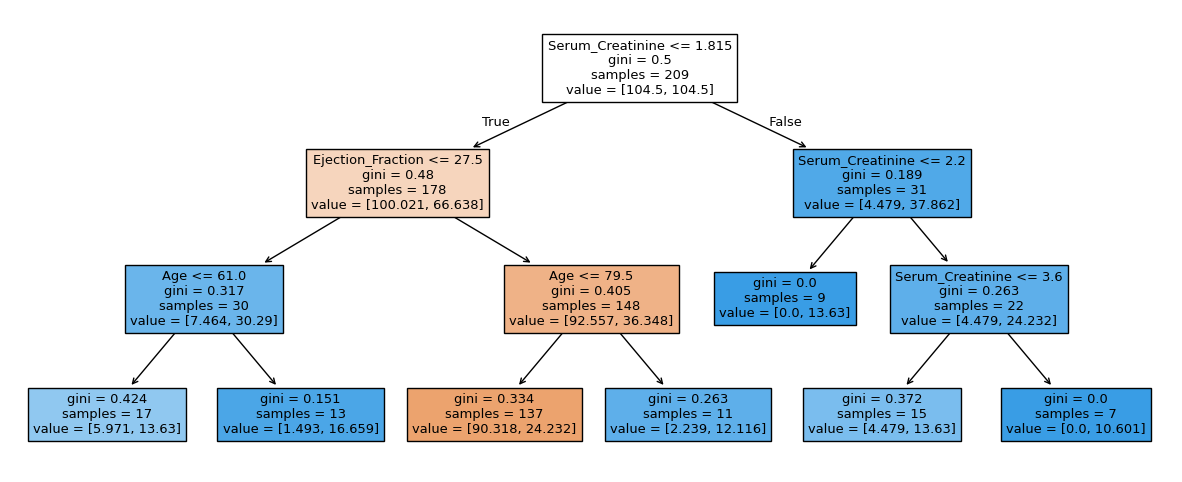

In [41]:
tr_mod = DecisionTreeClassifier(max_depth = 3, random_state = 31, class_weight = "balanced")
tr_mod.fit(X_train, y_train)

y_pred_tr = tr_mod.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tr), "\n")
print("Confusion Matrix", "\n", confusion_matrix(y_test, y_pred_tr), "\n")
print(classification_report(y_test, y_pred_tr))

plt.figure(figsize = (15,6))
plot_tree(tr_mod, filled = True, feature_names = X.columns)
plt.show()

In [75]:
rf_mod = RandomForestClassifier(max_depth = 3, random_state = 31, class_weight = "balanced")

rf_mod.fit(X_train, y_train)

y_pred_rf = rf_mod.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf), "\n")
print("Confusion Matrix", "\n", confusion_matrix(y_test, y_pred_rf), "\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7222222222222222 

Confusion Matrix 
 [[49 14]
 [11 16]] 

              precision    recall  f1-score   support

           0       0.82      0.78      0.80        63
           1       0.53      0.59      0.56        27

    accuracy                           0.72        90
   macro avg       0.68      0.69      0.68        90
weighted avg       0.73      0.72      0.73        90



In [86]:
y_prob_rf = rf_mod.predict_proba(X_test)[:, 1]

y_pred_custom = (y_prob_rf >= 0.35).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_custom), "\n")
print("Confusion Matrix", "\n", confusion_matrix(y_test, y_pred_custom), "\n")
print(classification_report(y_test, y_pred_custom), "\n")


print("100 % Recall for 'Death_event == 1' means that this model is able to capture all the patients who have a probability of 0.25 or more for the death event to occur")

Accuracy: 0.6777777777777778 

Confusion Matrix 
 [[40 23]
 [ 6 21]] 

              precision    recall  f1-score   support

           0       0.87      0.63      0.73        63
           1       0.48      0.78      0.59        27

    accuracy                           0.68        90
   macro avg       0.67      0.71      0.66        90
weighted avg       0.75      0.68      0.69        90
 

100 % Recall for 'Death_event == 1' means that this model is able to capture all the patients who have a probability of 0.25 or more for the death event to occur


In [77]:
pip install lightgbm

In [79]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(max_depth = 3, random_state = 31, class_weight = "balanced")
lgbm.fit(X_train, y_train)
y_lgbm = lgbm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred), "\n")
print("Confusion Matrix", confusion_matrix(y_test, y_lgbm), "\n")
print(classification_report(y_test, y_lgbm))

[LightGBM] [Info] Number of positive: 69, number of negative: 140
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000142 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 64
[LightGBM] [Info] Number of data points in the train set: 209, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [81]:
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

y_pred_cust = (y_prob_lgbm >= 0.25).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_cust), "\n")
print("Confusion Matrix", "\n", confusion_matrix(y_test, y_pred_cust), "\n")
print(classification_report(y_test, y_pred_cust))

Accuracy: 0.6888888888888889 

Confusion Matrix 
 [[39 24]
 [ 4 23]] 

              precision    recall  f1-score   support

           0       0.91      0.62      0.74        63
           1       0.49      0.85      0.62        27

    accuracy                           0.69        90
   macro avg       0.70      0.74      0.68        90
weighted avg       0.78      0.69      0.70        90



In [82]:
from xgboost import XGBClassifier

xgb = XGBClassifier(max_depth = 3, random_state = 31, class_weight = "balanced")
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb), "\n")
print("Confusion Matrix", "\n", confusion_matrix(y_test, y_pred_xgb), "\n")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:07:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7444444444444445 

Confusion Matrix 
 [[49 14]
 [ 9 18]] 

              precision    recall  f1-score   support

           0       0.84      0.78      0.81        63
           1       0.56      0.67      0.61        27

    accuracy                           0.74        90
   macro avg       0.70      0.72      0.71        90
weighted avg       0.76      0.74      0.75        90



In [85]:
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_customized = (y_prob_xgb >= 0.25).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_customized), "\n")
print("Confusion Matrix", "\n", confusion_matrix(y_test, y_pred_customized), "\n")
print(classification_report(y_test, y_pred_customized))

Accuracy: 0.7444444444444445 

Confusion Matrix 
 [[46 17]
 [ 6 21]] 

              precision    recall  f1-score   support

           0       0.88      0.73      0.80        63
           1       0.55      0.78      0.65        27

    accuracy                           0.74        90
   macro avg       0.72      0.75      0.72        90
weighted avg       0.79      0.74      0.75        90



In [88]:
print("Light GBM is the best model because the overall accuracy, recall, f1 score, and precision are very rewarding for a clinical setting!!!!")

Light GBM is the best model because the overall accuracy, recall, f1 score, and precision are very rewarding for a clinical setting!!!!
